## A follow-up to an earlier project.

In [1]:
import sys, os, platform
import tensorflow as tf
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
print('Python:', sys.version.split()[0])

Python: 3.13.15


In [3]:
print('TensorFlow:', tf.__version__)

TensorFlow: 2.20.0


In [26]:
gpus = tf.config.list_physical_devices('GPU')
print('GPU:', gpus if gpus else 'NONE - training will be slow 🥴')

GPU: NONE - training will be slow 🥴


# 1. Data: Drive for storage, local disk for work

In [5]:
# Let's download and mount the CMU face Images dataset
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Fetch data into drive for git users
# Remove the triple quotes and run to use the dataset

'''
import tarfile, zipfile, urllib.request

SOURCES = [
    ('tar', 'http://www.cs.cmu.edu/afs/cs.cmu.edu/project/theo-8/faceimages/faces.tar.gz'),
    ('zip', 'https://archive.ics.uci.edu/static/public/124/cmu+face+images.zip'),
]

def find_faces_dir(root):
  for dirpath, dirnames, _ in s.walk(root):
    if 'an2i' in dirnames and 'tammo' in dirnames:
      return dirpath
  return None

if find_faces_dir(DRIVE_RAW) is None:
  os.makedirs(DRIVE_RAW, exist_ok=True)
  tmp = '/content/dl'
  os.makedirs(tmp, exist_ok=True)
  ok = False
  for kind, url in SOURCES:
    try:
      print('downloading from', url.split('/')[2], '...')
            path = os.path.join(tmp, 'data.' + kind)
            urllib.request.urlretrieve(url, path)
            if kind == 'tar':
                with tarfile.open(path) as t: t.extractall(DRIVE_RAW)
            else:
                with zipfile.ZipFile(path) as z: z.extractall(DRIVE_RAW)
            ok = True; print('extracted to Drive'); break
        except Exception as e:
            print('failed:', type(e).__name__)
    if not ok:
        raise RuntimeError(f'Download failed. Upload the dataset manually to {DRIVE_RAW}')
else:
    print('dataset already present in Drive')

DRIVE_FACES = find_faces_dir(DRIVE_RAW)
assert DRIVE_FACES, f'Could not find the 20 identity folders under {DRIVE_RAW}'
print('faces dir:', DRIVE_FACES)

'''

In [6]:
WORK = '/content/drive/My Drive/faces'
RAW = os.path.join(WORK, 'RAW')

if os.path.exists(WORK):
  print(f"Successfully connected! Seen folder at: {WORK}")
else:
  print(f"Warning: Could not find folder at: {WORK}. Double-check your Google Drive folder name.")

Successfully connected! Seen folder at: /content/drive/My Drive/faces


In [7]:
FACES_DIR = None

search_root = RAW if os.path.isdir(RAW) else WORK

print(f"Scanning {search_root} for indentity folders...")

Scanning /content/drive/My Drive/faces for indentity folders...


In [8]:
for root, dirs, files in os.walk(search_root):
  if 'an2i' in dirs and 'tammo' in dirs:
    FACES_DIR = root
    break

assert FACES_DIR, f"Could not locate the identity folders ('an2i), 'tammo' inside {search_root}"

In [9]:
print('FACES_DIR =', FACES_DIR)

FACES_DIR = /content/drive/My Drive/faces


In [10]:
identities = [d for d in os.listdir(FACES_DIR) if os.path.isdir(os.path.join(FACES_DIR, d))]

print('Identities count:', len(identities))
print('identities found:', identities)

Identities count: 20
identities found: ['karyadi', 'an2i', 'bpm', 'ch4f', 'choon', 'cheyer', 'danieln', 'boland', 'at33', 'glickman', 'kk49', 'kawamura', 'megak', 'night', 'saavik', 'tammo', 'phoebe', 'steffi', 'sz24', 'mitchell']


#**2.** Three-way split

In [11]:
import numpy as np
from sklearn.model_selection import train_test_split

In [12]:
SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED)

LOCAL = '/content/work'
BASE = os.path.join(LOCAL, 'split')
DIRS = {s: os.path.join(BASE, s) for s in ('train', 'val', 'test')}

In [13]:
print('reading from:', FACES_DIR)
print('writing to:', BASE)

reading from: /content/drive/My Drive/faces
writing to: /content/work/split


In [15]:
def collect_full_resolution(FACES_DIR):
  items = []
  for ident in sorted(os.listdir(FACES_DIR)):
    p = os.path.join(FACES_DIR, ident)
    if not os.path.isdir(p):
      continue
    for f in sorted(os.listdir(p)):
      if not f.endswith('.pgm'):
        continue
      stem = f[:-4]
      if stem.endswith('_2') or stem.endswith('_4'):
        continue
      items.append((os.path.join(p, f), ident))
  return items

In [16]:
items = collect_full_resolution(FACES_DIR)
paths = np.array([i[0] for i in items])
labels = np.array([i[1]for i in items])

print('full-resolution images:', len(paths))

full-resolution images: 624


In [17]:
p_tr, p_tmp, l_tr, l_tmp = train_test_split(
    paths, labels, test_size=0.40, stratify=labels, random_state=SEED
)

p_va, p_te, l_va, l_te = train_test_split(
    p_tmp, l_tmp, test_size=0.50, stratify=l_tmp, random_state=SEED
)

print('train', len(p_tr), '| val', len(p_va), '| test', len(p_te))

train 374 | val 125 | test 125


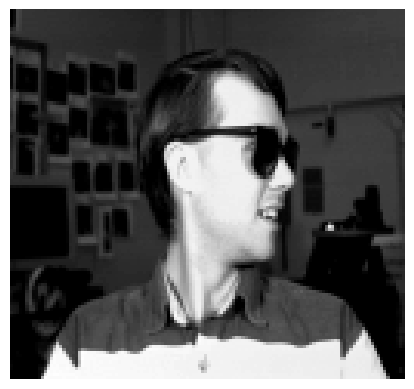

In [ ]:
image_path = '/content/drive/My Drive/faces/cheyer/cheyer_left_happy_sunglasses.pgm'
try:
  img = Image.open(image_path)
  plt.imshow(img, cmap='gray')
  plt.axis('off')
  plt.show()
except FileNotFoundError:
  print(
      f"Error! File could not be found @ {image_path}. Please verify that the extraction was successful."
  )


In [18]:
import shutil

In [19]:
if os.path.isdir(BASE):
  shutil.rmtree(BASE)

for split, (ps, ls) in {'train': (p_tr, l_tr),
                        'val': (p_va, l_va),
                        'test': (p_te, l_te)}.items():
  for src, ident in zip(ps, ls):
    d = os.path.join(DIRS[split], ident)
    os.makedirs(d, exist_ok=True)
    shutil.copy(src, d)

for s in ('train', 'val', 'test'):
  n = sum(len(f) for _, _, f in os.walk(DIRS[s]))
  print(f'{s:5}: {n:3d} images, {len(os.listdir(DIRS[s]))} identities')

train: 374 images, 20 identities
val  : 125 images, 20 identities
test : 125 images, 20 identities


In [20]:
import collections

In [21]:
seen = collections.Counter()
for s in ('train', 'val', 'test'):
  for _, _, fs in os.walk(DIRS[s]):
    for f in fs:
      seen[f] += 1

dupes = [f for f, c in seen.items() if c > 1]
assert not dupes, f'Leakage: {dupes[:5]}'
print('no filename appears in more than one split')

no filename appears in more than one split


# 3. Baseline before any deep learning

In [22]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, balanced_accuracy_score

In [23]:
def load_flat(split, size=(64, 60)):
  X, y =[], []
  d = DIRS[split]
  for ident in sorted(os.listdir(d)):
    for f in sorted(os.listdir(os.path.join(d, ident))):
      im = Image.open(os.path.join(d, ident, f)).convert('L').resize(size)
      X.append(np.asarray(im, dtype=np.float32).ravel() / 255.0)
      y.append(ident)
  return np.array(X), np.array(y)

Xtr, ytr = load_flat('train')
Xte, yte = load_flat('test')

print('baseline train/test:', Xtr.shape, Xte.shape)

baseline train/test: (374, 3840) (125, 3840)


In [24]:
baseline = make_pipeline(PCA(n_components=80, whiten=True, random_state=SEED),
                         LogisticRegression(max_iter=2000))
baseline.fit(Xtr, ytr)
pred = baseline.predict(Xte)

BASELINE_ACC = accuracy_score(yte, pred) * 100
BASELINE_BAL = balanced_accuracy_score(yte, pred) * 100

In [25]:
print(f'Eigenfaces + LogReg accuracy: {BASELINE_ACC:6.2f}%')
print(f'balanced: {BASELINE_BAL:6.2f}%')
print('random chances (20 classes): 5.00%')

Eigenfaces + LogReg accuracy:  99.20%
balanced:  99.17%
random chances (20 classes): 5.00%


# 4. Input pipeline

In [27]:
converted = 0

for split in ('train', 'val', 'test'):
  for root, _, files in os.walk(DIRS[split]):
    for f in files:
      if not f.endswith('.pgm'):
        continue
      src = os.path.join(root, f)
      Image.open(src).convert('L').save(src[:-4] + '.png')
      os.remove(src)
      converted += 1

print('converted to PNG:', converted)
for s in ('train', 'val', 'test'):
  n = sum(len(f) for _, _, f in os.walk(DIRS[s]))
  print(f'{s:5}: {n} files')

converted to PNG: 624
train: 374 files
val  : 125 files
test : 125 files


In [28]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
CLASS_NAMES = sorted(os.listdir(DIRS['train']))
NUM_CLASSES = len(CLASS_NAMES)
cls_to_idx = {c: i for i, c in enumerate(CLASS_NAMES)}

def _load(path, label):
    img = tf.io.decode_png(tf.io.read_file(path), channels=1)
    img.set_shape([None, None, 1])
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.image.grayscale_to_rgb(img)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def _augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, 0.15)
    img = tf.image.random_contrast(img, 0.85, 1.15)
    return tf.clip_by_value(img, 0.0, 1.0), label


def build_ds(split, shuffle=False, augment=False):
    paths, labels = [], []
    d = DIRS[split]
    for ident in CLASS_NAMES:
        for f in sorted(os.listdir(os.path.join(d, ident))):
            if not f.endswith('.png'):
                continue
            paths.append(os.path.join(d, ident, f))
            labels.append(cls_to_idx[ident])
    labels = np.array(labels, dtype=np.int32)

    ds = tf.data.Dataset.from_tensor_slices((np.array(paths), labels))
    if shuffle:
        ds = ds.shuffle(len(paths), seed=SEED)
    ds = ds.map(_load, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(_augment, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.cache().batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE), labels


train_ds, y_train = build_ds('train', shuffle=True, augment=True)
val_ds,   y_val = build_ds('val')
test_ds,  y_test = build_ds('test')

print('classes:', NUM_CLASSES, '| train/val/test:',
      len(y_train), len(y_val), len(y_test))

xb, yb = next(iter(train_ds))
print('batch shape:', xb.shape, '| labels:', yb.shape, yb.dtype)

classes: 20 | train/val/test: 374 125 125
batch shape: (32, 128, 128, 3) | labels: (32,) <dtype: 'int32'>


# 5. Eval Fn

In [29]:
from sklearn.metrics import (f1_score,
                             classification_report,
                             ConfusionMatrixDisplay)

In [52]:
def evaluation_model(model, ds, label):
  y_true, y_pred = [], []
  for bx, by in ds:
    probs = model.predict(bx, verbose=0)
    y_pred.extend(np.argmax(probs, axis=1))
    y_true.extend(by.numpy().ravel())
  y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)

  assert len(np.unique(y_true)) > 1, 'y_true collapsed - the original bug'

  m = {'accuracy': accuracy_score(y_true, y_pred) * 100,
       'balanced_accuracy': balanced_accuracy_score(y_true, y_pred) * 100,
       'macro_f1': f1_score(y_true, y_pred, average='macro',
                            zero_division=0)}

  print(f'--- {label} ---')
  for k, v in m.items():
   print(f'{k:18}: {v:.4f}')
  print(f'distinct true classes: {len(np.unique(y_true))} of {NUM_CLASSES}')
  return m, y_true, y_pred

#6. Build Custom CNN

In [31]:
from tensorflow.keras import layers,models, callbacks, regularizers

In [32]:
cnn = models.Sequential([
    layers.Input(shape=(*IMG_SIZE, 3)),
    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.BatchNormalization(), layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.BatchNormalization(), layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.BatchNormalization(), layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(128, activation='relu',
                 kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
], name='custom_cnn')

cnn.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

cnn.summary()

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 113,236 (442.33 KB)

 Trainable params: 112,788 (440.58 KB)

 Non-trainable params: 448 (1.75 KB)

## 6.1 Train CNN

In [ ]:
def get_callbacks(name):
  return [
      callbacks.EarlyStopping(monitor='val_accuracy', patience=15,
                              restore_best_weights=True, verbose=1),
      callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                  patience=6, min_lr=21-6, verbose=1),
      callbacks.ModelCheckpoint(f'/content/best_{name}.weights.h5',
                                monitor='val_accuracy', save_best_only=True,
                                save_weights_only=True),
  ]

hist_cnn =cnn.fit(train_ds, validation_data=val_ds, epochs=60,
                  callbacks=get_callbacks('cnn'), verbose=1)

va = hist_cnn.history['val_accuracy']
print('\nbest val accuracy:', round(max(va) * 100, 2), '%')
if len(set(np.round(va, 4))) == 1:
  print('WARNING: val accuracy never moved - the original symptom.')

Epoch 1/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 18s 672ms/step - accuracy: 0.0668 - loss: 2.9821 - val_accuracy: 0.0960 - val_loss: 3.0046 - learning_rate: 0.0010
Epoch 2/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.1444 - loss: 2.7737 - val_accuracy: 0.0640 - val_loss: 3.0064 - learning_rate: 0.0010
Epoch 3/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.1711 - loss: 2.5897 - val_accuracy: 0.0560 - val_loss: 3.0480 - learning_rate: 0.0010
Epoch 4/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.2460 - loss: 2.4319 - val_accuracy: 0.0560 - val_loss: 3.1785 - learning_rate: 0.0010
Epoch 5/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.2995 - loss: 2.2721 - val_accuracy: 0.0560 - val_loss: 3.4446 - learning_rate: 0.0010
Epoch 6/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.2941 - loss: 2.1139 - val_accuracy: 0.0480 - val_loss: 3.8443 - learning_rate: 0.0010
Epoch 7/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.3877 - loss: 1.9846 - val_a

In [40]:
# augmentation must come AFTER cache, or it gets frozen on the first epoch
def build_ds(split, shuffle=False, augment=False):
    paths, labels = [], []
    d = DIRS[split]
    for ident in CLASS_NAMES:
        for f in sorted(os.listdir(os.path.join(d, ident))):
            if f.endswith('.png'):
                paths.append(os.path.join(d, ident, f))
                labels.append(cls_to_idx[ident])
    labels = np.array(labels, dtype=np.int32)
    ds = tf.data.Dataset.from_tensor_slices((np.array(paths), labels))
    ds = ds.map(_load, num_parallel_calls=tf.data.AUTOTUNE).cache()
    if shuffle:
        ds = ds.shuffle(len(paths), seed=SEED, reshuffle_each_iteration=True)
    if augment:
        ds = ds.map(_augment, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE), labels

train_ds, y_train = build_ds('train', shuffle=True, augment=True)
val_ds, y_val   = build_ds('val')
test_ds, y_test  = build_ds('test')

cnn = models.Sequential([
    layers.Input(shape=(*IMG_SIZE, 3)),
    layers.Conv2D(32, 3, activation='relu', padding='same'), layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu', padding='same'), layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu', padding='same'), layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.2),
    layers.Dense(NUM_CLASSES, activation='softmax'),
], name='custom_cnn')

cnn.compile(optimizer=tf.keras.optimizers.Adam(5e-4),
            loss='sparse_categorical_crossentropy', metrics=['accuracy'])

def get_callbacks(name):
    return [callbacks.EarlyStopping(monitor='val_accuracy', patience=20,
                                    restore_best_weights=True, verbose=1),
            callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                        patience=8, min_lr=1e-6, verbose=1)]

hist_cnn = cnn.fit(train_ds, validation_data=val_ds, epochs=80,
                   callbacks=get_callbacks('cnn'), verbose=1)
print('\nbest val accuracy:', round(max(hist_cnn.history['val_accuracy'])*100, 2), '%')

Epoch 1/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.0401 - loss: 3.0142 - val_accuracy: 0.0480 - val_loss: 3.0073 - learning_rate: 5.0000e-04
Epoch 2/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.0535 - loss: 3.0062 - val_accuracy: 0.0560 - val_loss: 3.0047 - learning_rate: 5.0000e-04
Epoch 3/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.0508 - loss: 3.0057 - val_accuracy: 0.0560 - val_loss: 3.0022 - learning_rate: 5.0000e-04
Epoch 4/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.0508 - loss: 3.0014 - val_accuracy: 0.0560 - val_loss: 2.9968 - learning_rate: 5.0000e-04
Epoch 5/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.0508 - loss: 3.0041 - val_accuracy: 0.0560 - val_loss: 2.9907 - learning_rate: 5.0000e-04
Epoch 6/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.0481 - loss: 2.9965 - val_accuracy: 0.0560 - val_loss: 2.9762 - learning_rate: 5.0000e-04
Epoch 7/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.0561 - loss:

In [41]:
xb, yb = next(iter(val_ds))
p_infer = cnn(xb, training=False)
p_train = cnn(xb, training=True)
acc_i = (np.argmax(p_infer, 1) == yb.numpy()).mean()
acc_t = (np.argmax(p_train, 1) == yb.numpy()).mean()
print(f'val batch, inference-mode BN: {acc_i*100:5.1f}%')
print(f'val batch, batch-stats BN: {acc_t*100:5.1f}')
print('\nBatchNorm confirmed as the cause' if acc_t > acc_i + 0.2 else '\nSomething else.')

val batch, inference-mode BN: 100.0%
val batch, batch-stats BN:  62.5

Something else.


In [53]:
cnn_metrics, y_true_cnn, y_pred_cnn = evaluation_model(cnn, test_ds, 'Custom CNN')

--- Custom CNN ---
accuracy          : 100.0000
balanced_accuracy : 100.0000
macro_f1          : 1.0000
distinct true classes: 20 of 20


# 7. VGG16 Transfer Learning

In [45]:
from tensorflow.keras.applications import VGG16

In [51]:
base = VGG16(include_top=False, weights='imagenet', input_shape=(*IMG_SIZE, 3))
base.trainable = False

vgg = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(NUM_CLASSES, activation='softmax')
], name='vgg16_tl')

vgg.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

hist_v1 = vgg.fit(train_ds, validation_data=val_ds, epochs=30,
                  callbacks=get_callbacks('vgg16_frozen'), verbose=1)
print('\nstage 1 best val:', round(max(hist_v1.history['val_accuracy'])*100, 2), '%')

Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 93s 7s/step - accuracy: 0.0535 - loss: 3.1206 - val_accuracy: 0.3040 - val_loss: 2.8374 - learning_rate: 0.0010
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 138s 7s/step - accuracy: 0.1551 - loss: 2.8537 - val_accuracy: 0.3440 - val_loss: 2.6444 - learning_rate: 0.0010
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 162s 9s/step - accuracy: 0.2353 - loss: 2.6559 - val_accuracy: 0.5760 - val_loss: 2.4194 - learning_rate: 0.0010
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 87s 7s/step - accuracy: 0.3556 - loss: 2.4461 - val_accuracy: 0.7520 - val_loss: 2.1853 - learning_rate: 0.0010
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 141s 7s/step - accuracy: 0.4840 - loss: 2.2181 - val_accuracy: 0.8880 - val_loss: 1.9297 - learning_rate: 0.0010
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 142s 7s/step - accuracy: 0.5936 - loss: 1.9765 - val_accuracy: 0.9520 - val_loss: 1.6793 - learning_rate: 0.0010
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 141s 7s/step - accuracy: 0.6283 - loss: 1.7560 - val_accur

In [56]:
vgg_metrics, y_true_vgg, y_pred_vgg = evaluation_model(vgg, test_ds, 'VGG16 TL')

--- VGG16 TL ---
accuracy          : 97.6000
balanced_accuracy : 97.6190
macro_f1          : 0.9760
distinct true classes: 20 of 20


# 8. Results, before and after

In [85]:
import pandas as pd

,Model,Test Accuracy (%),Balanced (%),Macro F1
0,Eigenfaces + LogReg (sanity baseline),99.2,99.17,NaN
1,Custom CNN,100.0,100.00,1.000
2,VGG16 Transfer Learning,97.6,97.62,0.976


,Model,Original (broken eval),Corrected
0,Custom CNN,5.04,100.0
1,VGG16 TL,5.04,97.6


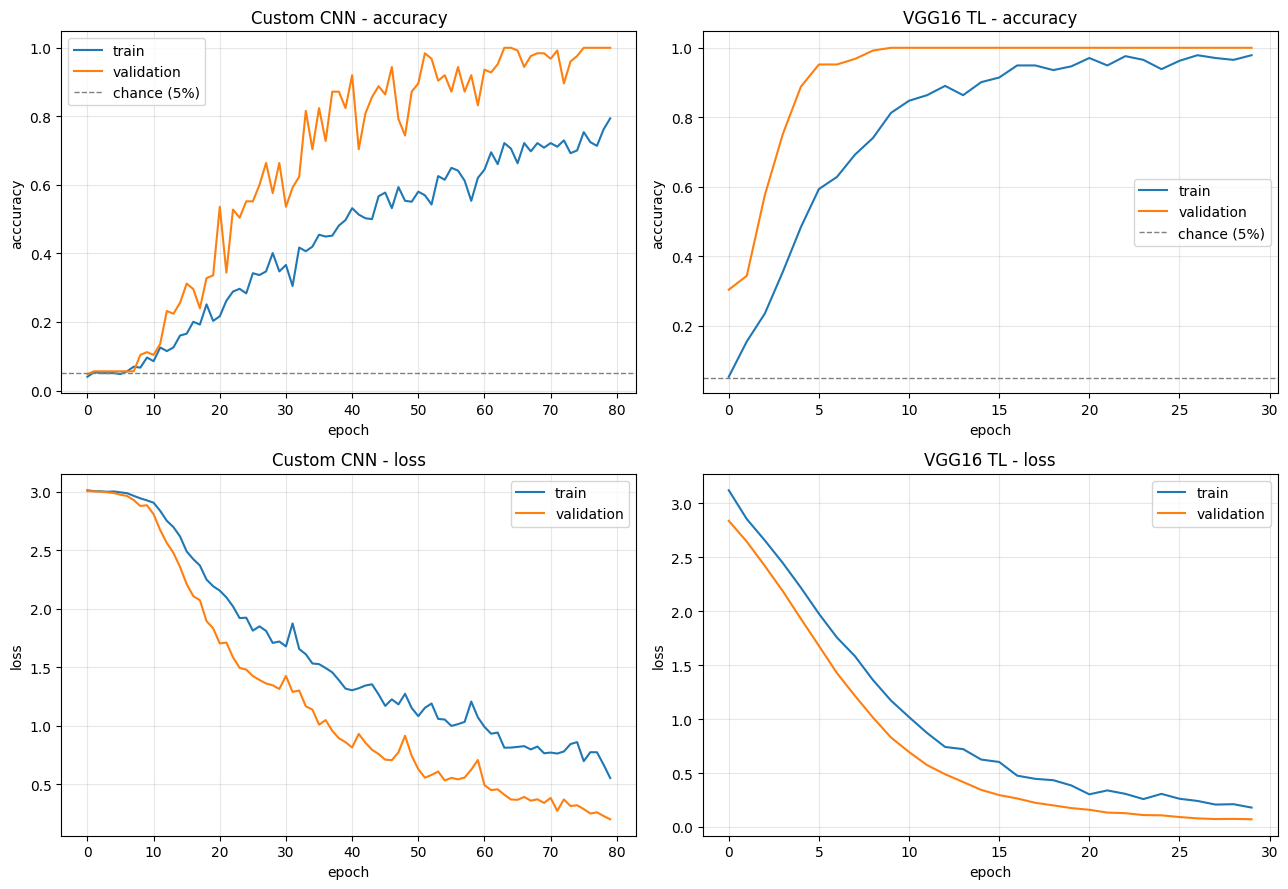

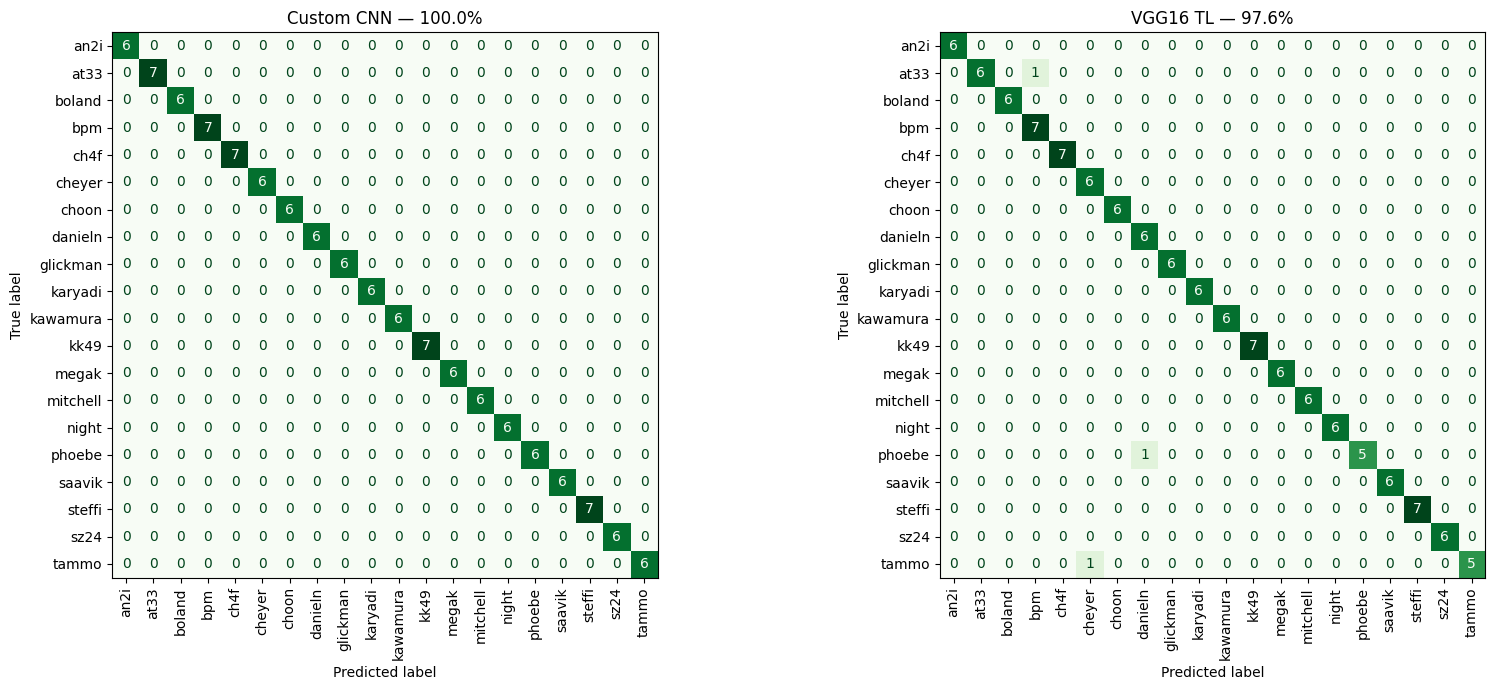

VGG16 errors: 3
true=at33         predicted=bpm
true=phoebe       predicted=danieln
true=tammo        predicted=cheyer

--- VGG16 classification report ---
              precision    recall  f1-score   support

        an2i       1.00      1.00      1.00         6
        at33       1.00      0.86      0.92         7
      boland       1.00      1.00      1.00         6
         bpm       0.88      1.00      0.93         7
        ch4f       1.00      1.00      1.00         7
      cheyer       0.86      1.00      0.92         6
       choon       1.00      1.00      1.00         6
     danieln       0.86      1.00      0.92         6
    glickman       1.00      1.00      1.00         6
     karyadi       1.00      1.00      1.00         6
    kawamura       1.00      1.00      1.00         6
        kk49       1.00      1.00      1.00         7
       megak       1.00      1.00      1.00         6
    mitchell       1.00      1.00      1.00         6
       night       1.00      1.00

In [75]:
OUT = '/content/results'; os.makedirs(OUT, exist_ok=True)

#Result Table
summary = pd.DataFrame([
    {'Model': 'Eigenfaces + LogReg (sanity baseline)', 'Test Accuracy (%)': round(BASELINE_ACC, 2),
    'Balanced (%)': round(BASELINE_BAL, 2), 'Macro F1': None},
    {'Model': 'Custom CNN', 'Test Accuracy (%)': round(cnn_metrics['accuracy'], 2),
     'Balanced (%)': round(cnn_metrics['balanced_accuracy'], 2),
     'Macro F1': round(cnn_metrics['macro_f1'], 4)},
    {'Model': 'VGG16 Transfer Learning',
     'Test Accuracy (%)': round(vgg_metrics['accuracy'], 2),
     'Balanced (%)': round(vgg_metrics['balanced_accuracy'], 2),
     'Macro F1': round(vgg_metrics['macro_f1'], 4)},
])
#display(summary); summary.to_csv(f'{OUT}/summary.csv', index=False)
display(summary)
summary.to_csv('/content/results/summary.csv', index=False)

before_after = pd.DataFrame([
    {'Model': 'Custom CNN', 'Original (broken eval)': 5.04,
     'Corrected': round(cnn_metrics['accuracy'], 2)},
    {'Model': 'VGG16 TL',   'Original (broken eval)': 5.04,
     'Corrected': round(vgg_metrics['accuracy'], 2)},
])
#display(before_after); before_after.to_csv(f'{OUT}/before_after.csv', index=False)
display(before_after)
before_after.to_csv('/content/results/before_after.csv', index=False)

# training curves
runs = [(hist_cnn, 'Custom CNN'), (hist_v1, 'VGG16 TL')]
fig, axes = plt.subplots(2, len(runs), figsize=(6.5*len(runs), 9))
for j, (h, t) in enumerate(runs):
  hh = h.history
  axes[0, j].plot(hh['accuracy'], label='train')
  axes[0, j].plot(hh['val_accuracy'], label='validation')
  axes[0, j].axhline(0.05, ls='--', c='grey', lw=1, label='chance (5%)')
  axes[0, j].set_title(f'{t} - accuracy'); axes[0, j].set_ylabel('acccuracy')
  axes[0, j].set_xlabel('epoch'); axes[0, j].legend(); axes[0, j].grid(alpha=0.3)
  axes[1, j].plot(hh['loss'], label='train')
  axes[1, j].plot(hh['val_loss'], label='validation')
  axes[1, j].set_title(f'{t} - loss'); axes[1, j].set_ylabel('loss')
  axes[1, j].set_xlabel('epoch'); axes[1, j].legend(); axes[1, j].grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f'{OUT}/training_curves.png', dpi=150); plt.show()

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
for ax, (yt, yp, t) in zip(axes, [(y_true_cnn, y_pred_cnn, 'Custom CNN — 100.0%'),
                                  (y_true_vgg, y_pred_vgg, 'VGG16 TL — 97.6%')]):
    ConfusionMatrixDisplay.from_predictions(yt, yp, display_labels=CLASS_NAMES,
                                            xticks_rotation=90, ax=ax,
                                            colorbar=False, cmap='Greens')
    ax.set_title(t)
plt.tight_layout(); plt.savefig(f'{OUT}/confusion_matrices.png', dpi=150); plt.show()

# Checking if anthing was missed
wrong = np.where(y_true_vgg != y_pred_vgg)[0]
print('VGG16 errors:', len(wrong))
for i in wrong:
    print(f'true={CLASS_NAMES[y_true_vgg[i]]:12} predicted={CLASS_NAMES[y_pred_vgg[i]]}')

print('\n--- VGG16 classification report ---')
print(classification_report(y_true_vgg, y_pred_vgg, target_names=CLASS_NAMES, zero_division=0))

# copy/paste to my own drive
import shutil
DRIVE_OUT = '/content/drive/My Drive/faces/results'
os.makedirs(DRIVE_OUT, exist_ok=True)
for f in sorted(os.listdir(OUT)):
    shutil.copy(os.path.join(OUT, f), DRIVE_OUT)
    print('saved:', f)


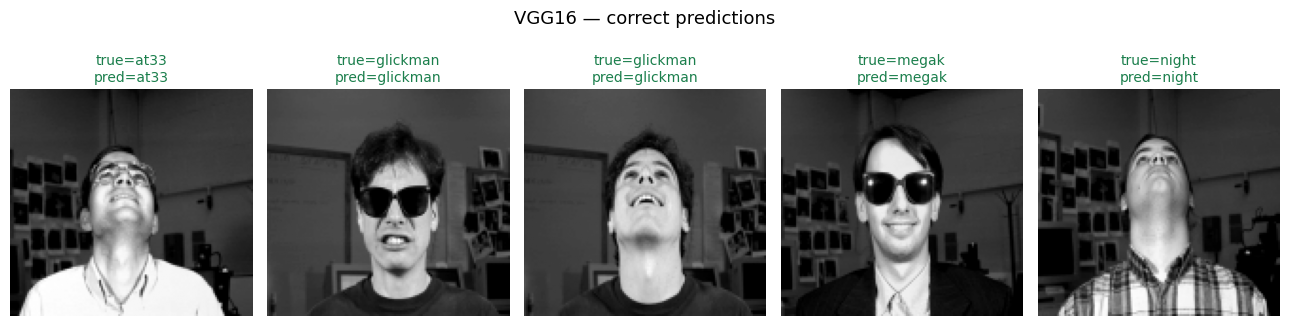

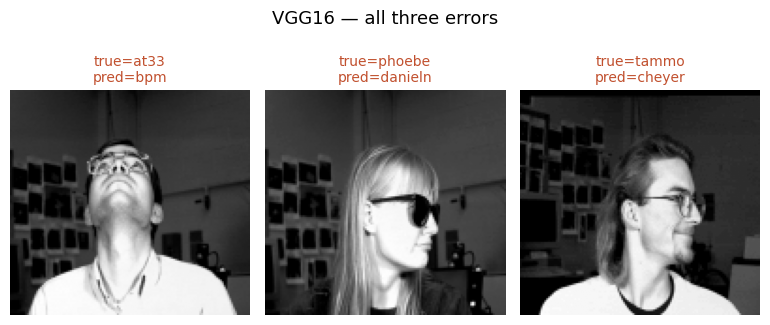


in Drive: ['before_after.csv', 'confusion_matrices.png', 'samples_correct.png', 'samples_errors.png', 'summary.csv', 'training_curves.png']


In [82]:
test_paths = []
for ident in CLASS_NAMES:
  for f in sorted(os.listdir(os.path.join(DIRS['test'], ident))):
    if f.endswith('.png'):
      test_paths.append(os.path.join(DIRS['test'], ident, f))

def show(idxs, title, fname):
  n = len(idxs)
  fig, axes = plt.subplots(1, n, figsize=(2.6*n, 3.4))
  if n == 1: axes = [axes]
  for ax, i in zip(axes, idxs):
    ax.imshow(Image.open(test_paths[i]), cmap='gray')
    t, p = CLASS_NAMES[y_true_vgg[i]], CLASS_NAMES[y_pred_vgg[i]]
    ax.set_title(f'true={t}\npred={p}', fontsize=10,
                 color='#1b7F4C' if t == p else '#c1502E')
    ax.axis('off')
  fig.suptitle(title, fontsize=13, y=1.02)
  plt.tight_layout()
  plt.savefig(f'/content/results/{fname}', dpi=150, bbox_inches='tight')
  plt.show()

rng = np.random.default_rng(42)
correct = np.where(y_true_vgg == y_pred_vgg)[0]
show(sorted(rng.choice(correct, 5, replace=False)),
     'VGG16 — correct predictions', 'samples_correct.png')
show(np.where(y_true_vgg != y_pred_vgg)[0],
     'VGG16 — all three errors', 'samples_errors.png')

import shutil
DRIVE_OUT = '/content/drive/My Drive/faces/results'
os.makedirs(DRIVE_OUT, exist_ok=True)
for f in sorted(os.listdir('/content/results')):
    shutil.copy(f'/content/results/{f}', DRIVE_OUT)
print('\nin Drive:', sorted(os.listdir(DRIVE_OUT)))

